# MODELO DE CLASIFICACIÓN DE IMAGENES PARA DETERMINAR NEUMONIA EN PACIENTES CON COVID 19 USANDO REDES NEURONALES CONVOLUCIONALES

## NOMBRE : Diego Alonso Tello Alva

## DATASET  [KAGGLE](https://www.kaggle.com/datasets/khoongweihao/covid19-xray-dataset-train-test-sets/data)

## IMPORTAMOS LIBRERIAS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# CARGAMOS PATH DE IMAGENES

In [3]:
BASE_DIR = '/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets'

In [4]:
import os
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALIDATION_DIR = os.path.join(BASE_DIR, 'validation')
TEST_DIR = os.path.join(BASE_DIR, 'test')
print(TRAIN_DIR)
print(VALIDATION_DIR)
print(TEST_DIR)

/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/train
/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/validation
/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/test


## 1 -CREO LOS DIRECTORIOS PARA CADA CONJUNTO DE DATOS DE NORMAL Y PNEUMONIA

In [5]:
C1 = 'normal'
C2 = 'pneumonia'

In [6]:
train_c1_dir = os.path.join(TRAIN_DIR,C1)
train_c2_dir = os.path.join(TRAIN_DIR,C2)

validation_c1_dir = os.path.join(VALIDATION_DIR, C1)
validation_c2_dir = os.path.join(VALIDATION_DIR, C2)

test_c1_dir = os.path.join(TEST_DIR, C1)
test_c2_dir = os.path.join(TEST_DIR, C2)

print(train_c1_dir)
print(train_c2_dir)
print(validation_c1_dir)
print(validation_c2_dir)
print(test_c1_dir)
print(test_c2_dir)

/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/train/normal
/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/train/pneumonia
/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/validation/normal
/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/validation/pneumonia
/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/test/normal
/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/test/pneumonia


# MOSTRAMOS UNA IMAGEN

In [7]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def mostrar_imagenes_aleatorias(directorio, num_imagenes=5):
    # Obtener lista de archivos de imagen en el directorio
    imagenes = os.listdir(directorio)

    # Filtrar archivos para obtener solo las imágenes (por ejemplo, con extensiones jpg o png)
    imagenes = [img for img in imagenes if img.endswith(('.jpg', '.jpeg', '.png'))]

    # Seleccionar imágenes aleatorias
    imagenes_aleatorias = random.sample(imagenes, min(num_imagenes, len(imagenes)))

    # Mostrar las imágenes seleccionadas
    for img_name in imagenes_aleatorias:
        img_path = os.path.join(directorio, img_name)
        img = mpimg.imread(img_path)

        plt.figure()
        plt.imshow(img)
        plt.title(img_name)
        plt.axis('off')  # Ocultar los ejes
        plt.show()

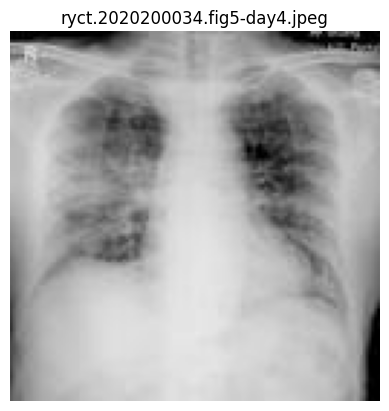

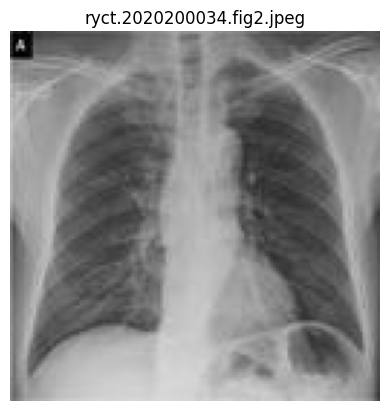

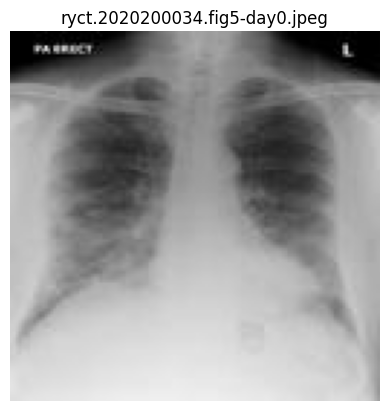

In [8]:
mostrar_imagenes_aleatorias(test_c2_dir,3)

# Mostramos que cantidades de archivos hay en cada carpeta

In [9]:
dataset_dir = [train_c1_dir,train_c2_dir,validation_c1_dir,validation_c2_dir,test_c1_dir,test_c2_dir]
for img_dir in dataset_dir:
  print(f" en directorio :{img_dir} hay {len(os.listdir(img_dir))} imagenes")

 en directorio :/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/train/normal hay 74 imagenes
 en directorio :/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/train/pneumonia hay 74 imagenes
 en directorio :/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/validation/normal hay 27 imagenes
 en directorio :/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/validation/pneumonia hay 27 imagenes
 en directorio :/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/test/normal hay 3 imagenes
 en directorio :/content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/test/pneumonia hay 3 imagenes


# CREAMOS OBJETOS PARA CARGAR EL CONJUNTO DE ENTRENAMIENTO VALIDACIÓN Y PRUEBAS

In [10]:
import tensorflow as tf
print(tf.__version__)

2.19.0


# CREAMOS OBJETOS PARA CARGAR EL CONJUNTO DE ENTRENAMIENTO VALIDACIÓN Y PRUEBAS CON DATA AUGMENTATION

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_data = ImageDataGenerator(rescale=1. /255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)
val_data = ImageDataGenerator(rescale=1. /255)
test_data = ImageDataGenerator(rescale=1. /255)

## CARGAMOS LOS CONJUNTOS DE DATOS CON LOS OBJETOS CREADOS

In [12]:
training_set = train_data.flow_from_directory(
    TRAIN_DIR,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)
validation_set = train_data.flow_from_directory(
    VALIDATION_DIR,
    target_size=(64,64),
    batch_size=20,
    class_mode='binary'
)
test_set = train_data.flow_from_directory(
    TEST_DIR,
    target_size=(64,64),
    class_mode='binary'
)

Found 148 images belonging to 2 classes.
Found 54 images belonging to 2 classes.
Found 6 images belonging to 2 classes.


# CREAMOS MODELO DE RED NEURONAL CONVOLUCIONAL

In [13]:
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

modelo = Sequential()
modelo.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
modelo.add(MaxPooling2D((2,2)))
modelo.add(Conv2D(32,(3,3),activation='relu'))
modelo.add(MaxPooling2D((2,2)))
modelo.add(Flatten())
modelo.add(Dense(128,activation='relu'))
modelo.add(Dropout(0.5))
modelo.add(Dense(1,activation='sigmoid'))

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

# COMPILAMOS LA RED NEURONAL

In [14]:
modelo.compile(loss="binary_crossentropy",
               optimizer='adam',
               metrics=['accuracy'])

# ENTRENAMOS EL MODELO

In [15]:
history = modelo.fit(training_set,epochs=20,batch_size=100,validation_data=validation_set)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 52s 10s/step - accuracy: 0.5270 - loss: 0.7061 - val_accuracy: 0.7407 - val_loss: 0.5940
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - accuracy: 0.7095 - loss: 0.5971 - val_accuracy: 0.5741 - val_loss: 0.5850
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - accuracy: 0.6689 - loss: 0.6183 - val_accuracy: 0.8519 - val_loss: 0.4799
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - accuracy: 0.7365 - loss: 0.5783 - val_accuracy: 0.8704 - val_loss: 0.4298
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - accuracy: 0.7432 - loss: 0.5196 - val_accuracy: 0.9259 - val_loss: 0.3552
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - accuracy: 0.7770 - loss: 0.4757 - val_accuracy: 0.9074 - val_loss: 0.2964
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.7770 - loss: 0.4628 - val_accuracy: 0.9259 - val_loss: 0.2692
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 0.7297 - loss: 0.5013 - val_accuracy: 0.9259 - val_loss: 

# GRAFICAMOS ACCURACY Y LOSS

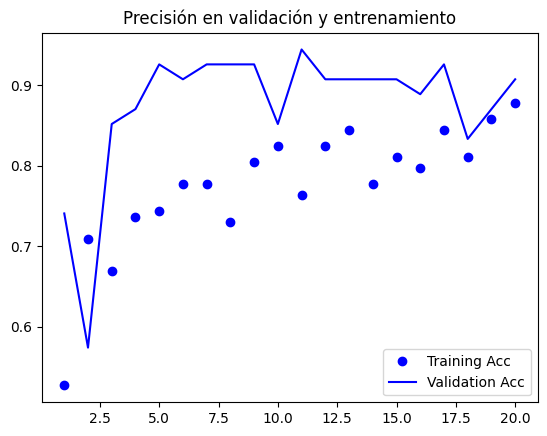

In [16]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1,len(acc)+1)

plt.plot(epochs,acc,'bo',label='Training Acc')
plt.plot(epochs,val_acc,'b',label='Validation Acc')
plt.title('Precisión en validación y entrenamiento')
plt.legend()
plt.show()

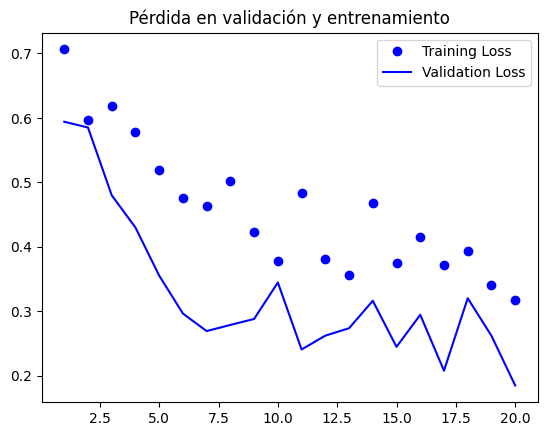

In [17]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs,loss,'bo',label='Training Loss')
plt.plot(epochs,val_loss,'b',label='Validation Loss')
plt.title('Pérdida en validación y entrenamiento')
plt.legend()
plt.show()

# EVALUAMOS EL MODELO

In [18]:
evaluacion = modelo.evaluate(test_set)
print(evaluacion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step - accuracy: 0.8333 - loss: 0.4692
[0.46919092535972595, 0.8333333134651184]


# REALIZAMOS PREDICCIÓN DEL MODELO

In [19]:
!ls /content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/test/normal

NORMAL2-IM-0035-0001.jpeg  NORMAL2-IM-0052-0001.jpeg  NORMAL2-IM-0058-0001.jpeg


In [20]:
!ls /content/drive/MyDrive/Trabajo_Final_Modulo_6/datasets/test/pneumonia

ryct.2020200034.fig2.jpeg	ryct.2020200034.fig5-day4.jpeg
ryct.2020200034.fig5-day0.jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
predicción :  [[0.]]
es normal


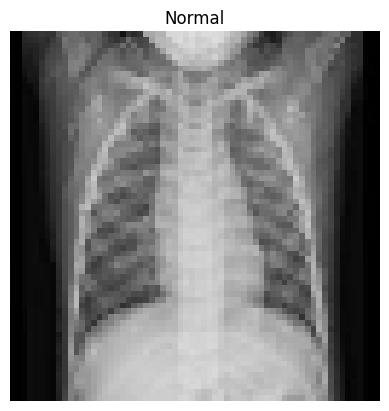

In [21]:
from keras.preprocessing import image
normal = image.load_img(test_c1_dir + "/NORMAL2-IM-0035-0001.jpeg",target_size=(64,64))
pneumonia = image.load_img(test_c2_dir + "/ryct.2020200034.fig5-day0.jpeg",target_size=(64,64))
imagen_prueba = normal

test_image = image.img_to_array(imagen_prueba)
test_image = np.expand_dims(test_image,axis=0)
training_set.class_indices


result = modelo.predict(test_image)
print("predicción : ",result)
if result[0][0] == 0:
  print("es normal")
  plt.imshow(imagen_prueba)
  plt.title('Normal')
  plt.axis('off')
  plt.show()
else:
  print("tiene pneumonia")
  plt.imshow(imagen_prueba)
  plt.title('PNEUMONIA')
  plt.axis('off')
  plt.show()

In [22]:
modelo.save("cnn_neumonia.keras")